## DAY 2 : Logistic Regression

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.shape

(400, 5)

In [4]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

# Preprocessing Data

In [5]:
df1=df.copy()
df1.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
df1.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df1['Gender']=df1['Gender'].map({'Male':0,'Female':1})

In [8]:
df1.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


In [9]:
X=df1[['Gender','Age','EstimatedSalary']]
y=df1['Purchased']
print(X.shape)
print(y.shape)

(400, 3)
(400,)


# split and scale data

In [10]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_Scaled= scaler.fit_transform(X_train)
X_test_Scaled= scaler.transform(X_test)

## Train Logistic Regression

In [11]:
model = LogisticRegression()
model.fit(X_train_Scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
coef_df= pd.DataFrame({
    'feature':['Gender','Age','EstimatedSalary'],
    'Coefficient':model.coef_[0]
})

print(coef_df.to_string(index=False))

        feature  Coefficient
         Gender    -0.168389
            Age     2.165515
EstimatedSalary     1.216358


# Evaluate the model

In [13]:
y_pred = model.predict(X_test_Scaled)
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.81

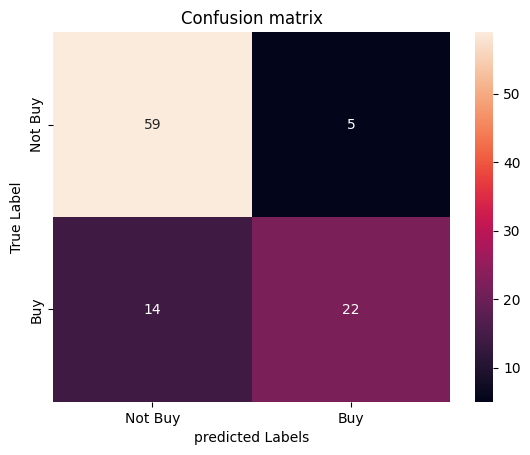

In [14]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True, xticklabels=['Not Buy' , 'Buy'],
    yticklabels=['Not Buy' , 'Buy'])
plt.xlabel('predicted Labels')
plt.ylabel('True Label')
plt.title('Confusion matrix')
plt.show()

In [15]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        64
           1       0.81      0.61      0.70        36

    accuracy                           0.81       100
   macro avg       0.81      0.77      0.78       100
weighted avg       0.81      0.81      0.80       100



## Day 3: Decision Tree

## TRAIN DEEP TREE (OVERFITTED)

In [16]:
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
deep_tree.fit(X_train, y_train)

# Predictions
train_pred_deep = deep_tree.predict(X_train)
test_pred_deep = deep_tree.predict(X_test)

# Accuracy
train_acc_deep = accuracy_score(y_train, train_pred_deep)
test_acc_deep = accuracy_score(y_test, test_pred_deep)

print(f"\n📊 Training Accuracy: {train_acc_deep:.2%}")
print(f"📊 Testing Accuracy:  {test_acc_deep:.2%}")
print(f"📊 Gap: {train_acc_deep - test_acc_deep:.2%}")

print(f"\n🌳 Tree Depth: {deep_tree.get_depth()}")
print(f"🍃 Number of leaves: {deep_tree.get_n_leaves()}")


📊 Training Accuracy: 99.67%
📊 Testing Accuracy:  88.00%
📊 Gap: 11.67%

🌳 Tree Depth: 10
🍃 Number of leaves: 40


 ## TRAIN SHALLOW TREE (REGULARIZED)

In [17]:
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)

# Predictions
train_pred_shallow = shallow_tree.predict(X_train)
test_pred_shallow = shallow_tree.predict(X_test)

# Accuracy
train_acc_shallow = accuracy_score(y_train, train_pred_shallow)
test_acc_shallow = accuracy_score(y_test, test_pred_shallow)

print(f"\n📊 Training Accuracy: {train_acc_shallow:.2%}")
print(f"📊 Testing Accuracy:  {test_acc_shallow:.2%}")
print(f"📊 Gap: {train_acc_shallow - test_acc_shallow:.2%}")

print(f"\n🌳 Tree Depth: {shallow_tree.get_depth()}")
print(f"🍃 Number of leaves: {shallow_tree.get_n_leaves()}")


📊 Training Accuracy: 93.67%
📊 Testing Accuracy:  88.00%
📊 Gap: 5.67%

🌳 Tree Depth: 3
🍃 Number of leaves: 7


## COMPARE RESULTS

In [18]:

comparison = pd.DataFrame({
    'Tree Type': ['Deep (Overfitted)', 'Shallow (Regularized)'],
    'Train Accuracy': [f"{train_acc_deep:.2%}", f"{train_acc_shallow:.2%}"],
    'Test Accuracy': [f"{test_acc_deep:.2%}", f"{test_acc_shallow:.2%}"],
    'Gap': [f"{train_acc_deep - test_acc_deep:.2%}", 
            f"{train_acc_shallow - test_acc_shallow:.2%}"],
    'Depth': [deep_tree.get_depth(), shallow_tree.get_depth()],
    'Leaves': [deep_tree.get_n_leaves(), shallow_tree.get_n_leaves()]
})

print("\n", comparison.to_string(index=False))


             Tree Type Train Accuracy Test Accuracy    Gap  Depth  Leaves
    Deep (Overfitted)         99.67%        88.00% 11.67%     10      40
Shallow (Regularized)         93.67%        88.00%  5.67%      3       7


## 5: VISUALIZE THE TREES

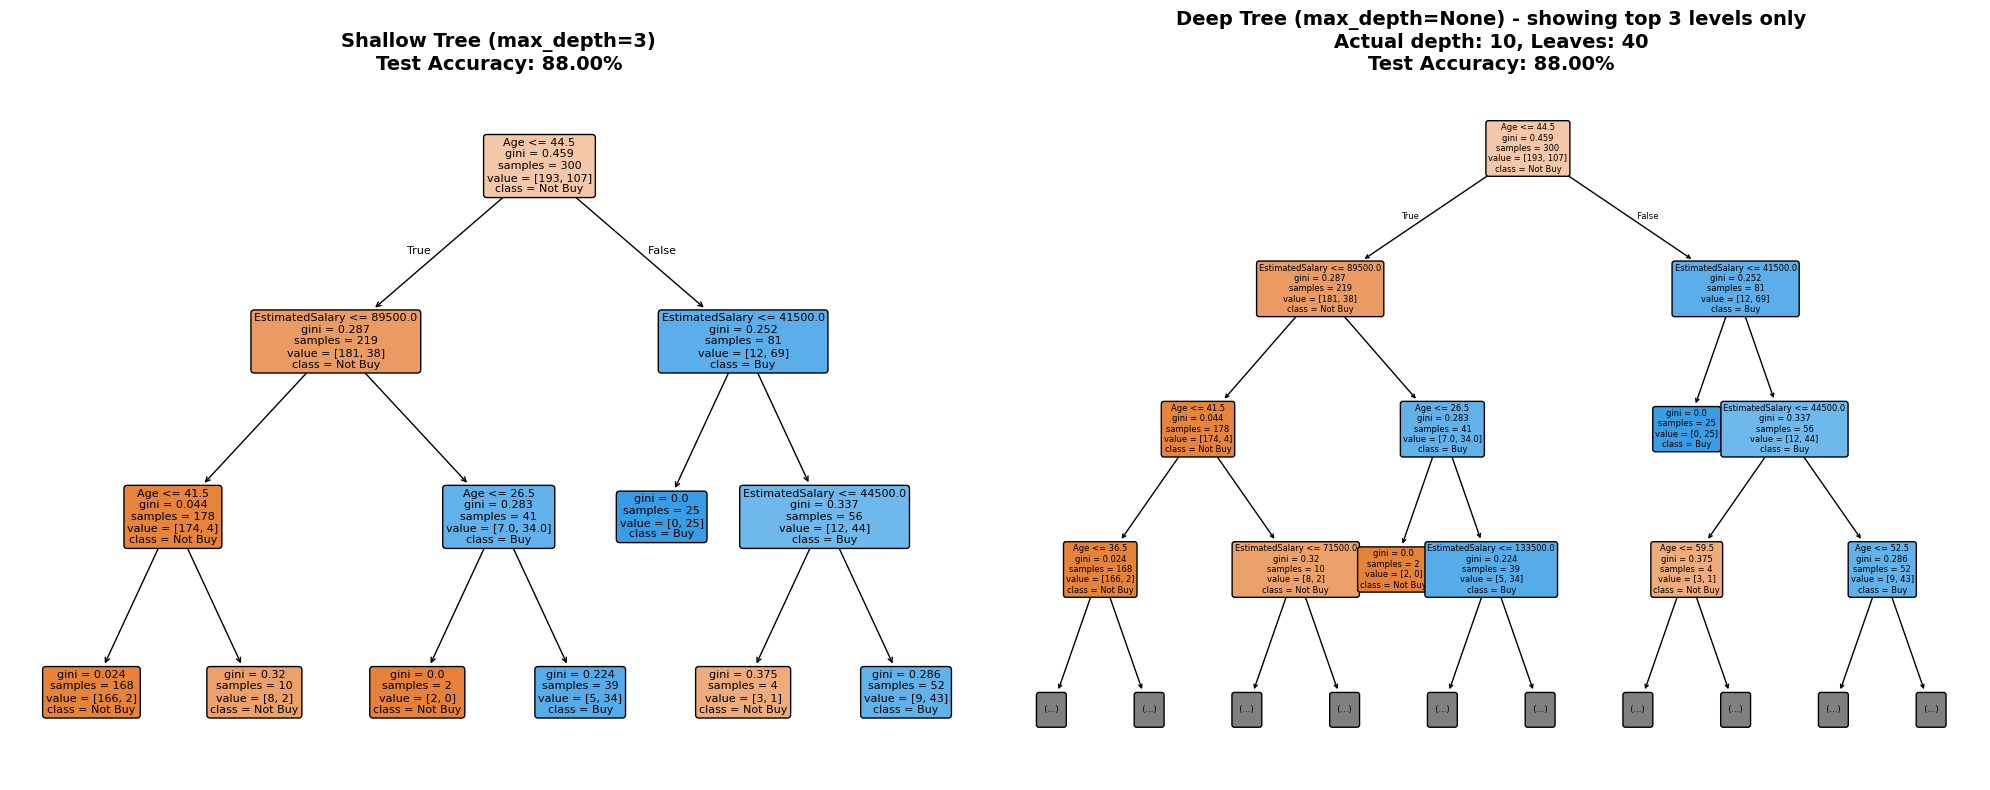

In [19]:
plt.figure(figsize=(20, 8))

# Plot shallow tree (full)
plt.subplot(1, 2, 1)
plot_tree(shallow_tree, feature_names=X.columns, 
          class_names=['Not Buy', 'Buy'],
          filled=True, rounded=True, fontsize=8)
plt.title(f'Shallow Tree (max_depth=3)\nTest Accuracy: {test_acc_shallow:.2%}', 
          fontsize=14, fontweight='bold')

# Plot deep tree (showing only top levels - it's too big!)
plt.subplot(1, 2, 2)
plot_tree(deep_tree, feature_names=X.columns, 
          class_names=['Not Buy', 'Buy'],
          filled=True, rounded=True, fontsize=6, max_depth=3)
plt.title(f'Deep Tree (max_depth=None) - showing top 3 levels only\n'
          f'Actual depth: {deep_tree.get_depth()}, Leaves: {deep_tree.get_n_leaves()}\n'
          f'Test Accuracy: {test_acc_deep:.2%}', 
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# TEST DIFFERENT DEPTHS

Depth  1: Train Acc = 83.33%, Test Acc = 85.00%
Depth  2: Train Acc = 92.33%, Test Acc = 89.00%
Depth  3: Train Acc = 93.67%, Test Acc = 88.00%
Depth  4: Train Acc = 94.00%, Test Acc = 89.00%
Depth  5: Train Acc = 94.67%, Test Acc = 89.00%
Depth  6: Train Acc = 95.33%, Test Acc = 87.00%
Depth  7: Train Acc = 97.67%, Test Acc = 87.00%
Depth  8: Train Acc = 98.33%, Test Acc = 89.00%
Depth  9: Train Acc = 99.00%, Test Acc = 86.00%
Depth 10: Train Acc = 99.67%, Test Acc = 88.00%


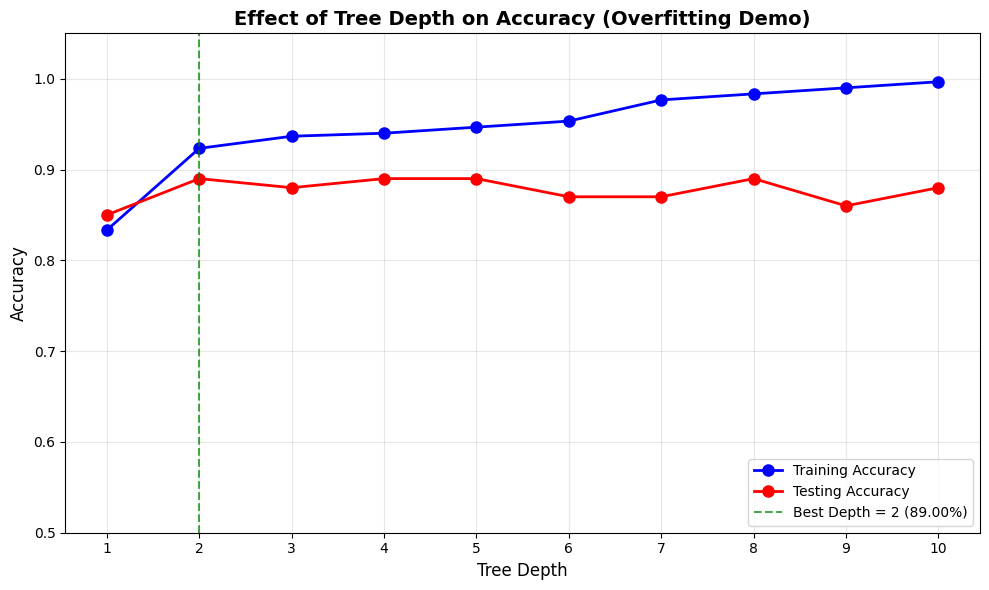


✅ Best depth: 2 (Test accuracy: 89.00%)


In [20]:

depths = range(1, 11)
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, tree.predict(X_test)))
    
    print(f"Depth {depth:2}: Train Acc = {train_scores[-1]:.2%}, "
          f"Test Acc = {test_scores[-1]:.2%}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(depths, test_scores, 'r-o', label='Testing Accuracy', linewidth=2, markersize=8)
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of Tree Depth on Accuracy (Overfitting Demo)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.ylim(0.5, 1.05)

# Highlight the best depth
best_depth = depths[np.argmax(test_scores)]
best_acc = max(test_scores)
plt.axvline(x=best_depth, color='green', linestyle='--', alpha=0.7, 
            label=f'Best Depth = {best_depth} ({best_acc:.2%})')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ Best depth: {best_depth} (Test accuracy: {best_acc:.2%})")

 ## CONFUSION MATRIX FOR BEST TREE

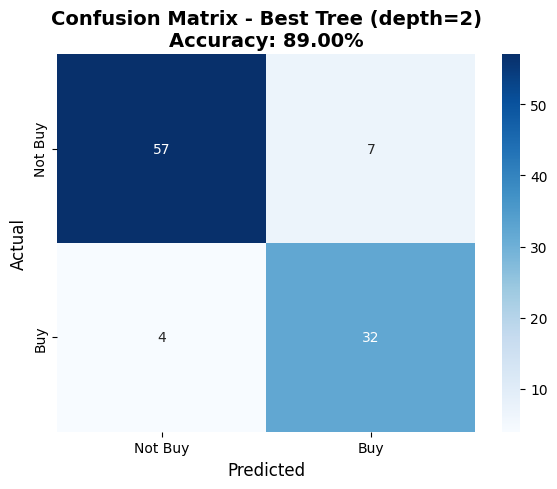

In [21]:
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)
y_pred_best = best_tree.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Buy', 'Buy'],
            yticklabels=['Not Buy', 'Buy'])
plt.title(f'Confusion Matrix - Best Tree (depth={best_depth})\nAccuracy: {best_acc:.2%}', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()



Cell	Value	Meaning

TN (True Negatives)	57	Correctly predicted NOT BUY

FP (False Positives)	7	Wrongly predicted BUY (actually didn't)

FN (False Negatives)	4	Wrongly predicted NOT BUY (actually did)

TP (True Positives)	32	Correctly predicted BUY

In [22]:
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not Buy', 'Buy']))


📋 Classification Report:
              precision    recall  f1-score   support

     Not Buy       0.93      0.89      0.91        64
         Buy       0.82      0.89      0.85        36

    accuracy                           0.89       100
   macro avg       0.88      0.89      0.88       100
weighted avg       0.89      0.89      0.89       100




Metric	Value	Meaning

Precision	0.93	When model says "Not Buy", it's right 93% of the time

Recall	0.89	Model caught 89% of actual "Not Buy" cases

F1-score	0.91	Balance of precision & recall

## COMPARE WITH LOGISTIC REGRESSION (DAY 2)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Train Logistic Regression (from Day 2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"\n📊 Logistic Regression Test Accuracy: {lr_acc:.2%}")
print(f"🌳 Decision Tree (depth={best_depth}) Test Accuracy: {best_acc:.2%}")

if best_acc > lr_acc:
    print(f"\n✅ Decision Tree performed better by {best_acc - lr_acc:.2%}")
else:
    print(f"\n✅ Logistic Regression performed better by {lr_acc - best_acc:.2%}")


📊 Logistic Regression Test Accuracy: 81.00%
🌳 Decision Tree (depth=2) Test Accuracy: 89.00%

✅ Decision Tree performed better by 8.00%


## VISUALIZE DECISION BOUNDARY

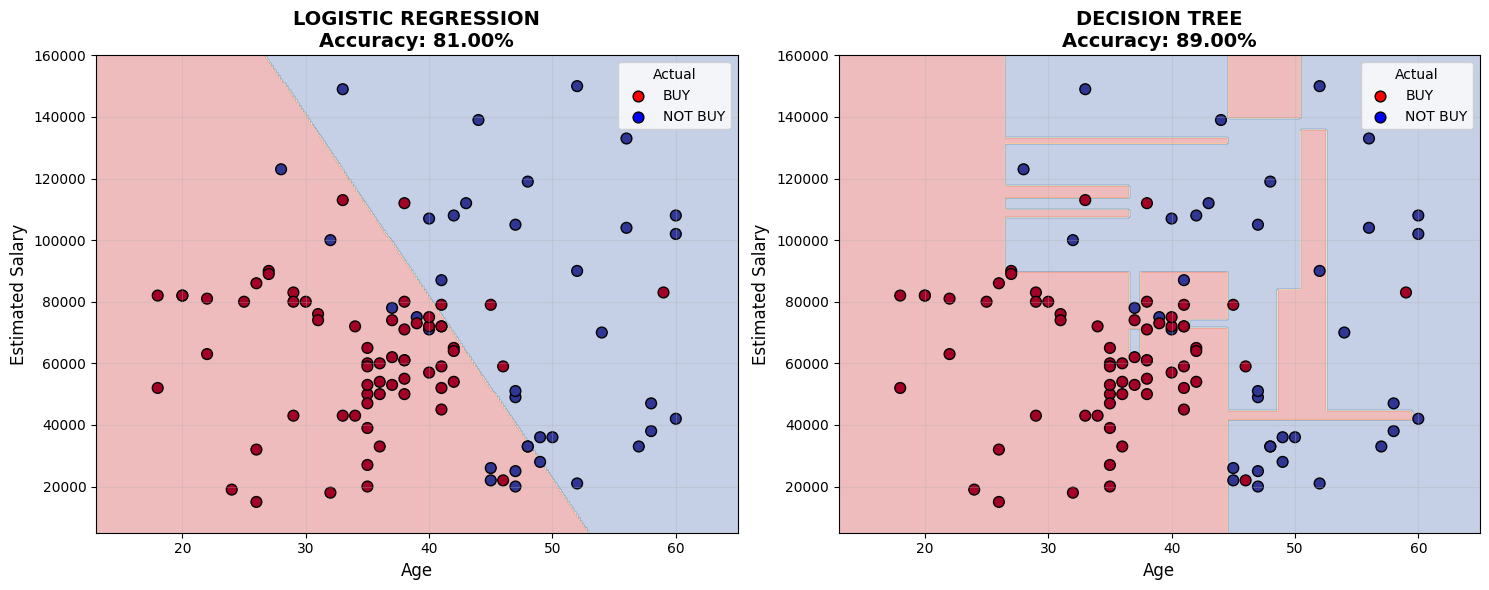

In [24]:
# Create mesh grid
age_range = np.linspace(X['Age'].min()-5, X['Age'].max()+5, 300)
sal_range = np.linspace(X['EstimatedSalary'].min()-10000, X['EstimatedSalary'].max()+10000, 300)
xx, yy = np.meshgrid(age_range, sal_range)

# Create grid
grid = np.c_[np.zeros(xx.ravel().shape), xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=['Gender', 'Age', 'EstimatedSalary'])

# Get predictions
Z_lr = model.predict(scaler.transform(grid_df)).reshape(xx.shape)
Z_dt = tree.predict(grid_df).reshape(xx.shape)

# Create plots
plt.figure(figsize=(15, 6))

# LEFT: Logistic Regression
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_lr, alpha=0.3, cmap='RdYlBu')
plt.scatter(X_test['Age'], X_test['EstimatedSalary'], 
            c=y_test, cmap='RdYlBu', edgecolors='black', s=60)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Estimated Salary', fontsize=12)
plt.title(f'LOGISTIC REGRESSION\nAccuracy: {accuracy:.2%}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add legend for left plot
red_patch = plt.scatter([], [], c='red', edgecolors='black', s=60, label='BUY')
blue_patch = plt.scatter([], [], c='blue', edgecolors='black', s=60, label='NOT BUY')
plt.legend(handles=[red_patch, blue_patch], title="Actual", loc="upper right")

# RIGHT: Decision Tree
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_dt, alpha=0.3, cmap='RdYlBu')
plt.scatter(X_test['Age'], X_test['EstimatedSalary'], 
            c=y_test, cmap='RdYlBu', edgecolors='black', s=60)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Estimated Salary', fontsize=12)
plt.title(f'DECISION TREE\nAccuracy: {best_acc:.2%}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add legend for right plot
red_patch = plt.scatter([], [], c='red', edgecolors='black', s=60, label='BUY')
blue_patch = plt.scatter([], [], c='blue', edgecolors='black', s=60, label='NOT BUY')
plt.legend(handles=[red_patch, blue_patch], title="Actual", loc="upper right")

plt.tight_layout()
plt.show()


# Day 4 : Random Forest

 ## TRAIN RANDOM FOREST

In [25]:
# Random Forest with 100 trees
rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=best_depth,  
    random_state=42,
    n_jobs=-1             
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"\n📊 Random Forest Test Accuracy: {rf_acc:.2%}")
print(f"🌲 Number of trees: {rf_model.n_estimators}")


📊 Random Forest Test Accuracy: 90.00%
🌲 Number of trees: 100


##  FEATURE IMPORTANCE


📌 What the Random Forest thinks is important:
        Feature  Importance
            Age    0.557613
EstimatedSalary    0.436280
         Gender    0.006106


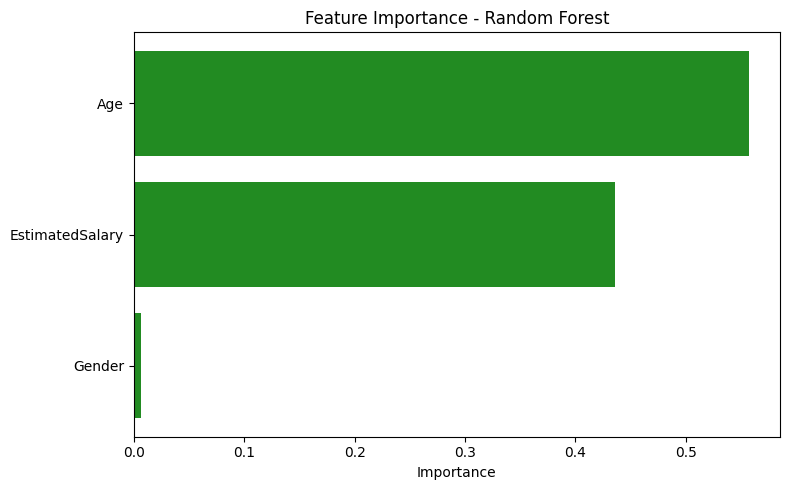

In [26]:
# Get feature importances
importances = rf_model.feature_importances_
features = X.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n📌 What the Random Forest thinks is important:")
print(importance_df.to_string(index=False))

# Visualize
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

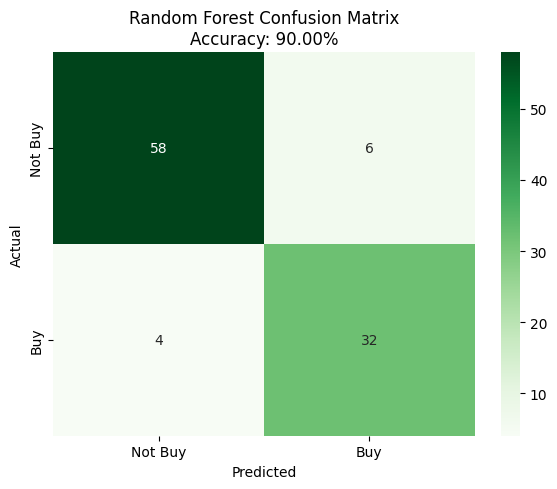

In [27]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Buy', 'Buy'],
            yticklabels=['Not Buy', 'Buy'])
plt.title(f'Random Forest Confusion Matrix\nAccuracy: {rf_acc:.2%}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Cell	Value	Meaning

TN (True Negatives)	58	Correctly predicted NOT BUY

FP (False Positives)	6	Wrongly predicted BUY (actually didn't)

FN (False Negatives)	4	Wrongly predicted NOT BUY (actually did)

TP (True Positives)	32	Correctly predicted BUY

##  COMPARE SINGLE TREE vs RANDOM FOREST

In [28]:
comparison = pd.DataFrame({
    'Model': ['Single Decision Tree', 'Random Forest (100 trees)'],
    'Test Accuracy': [f"{best_acc:.2%}", f"{rf_acc:.2%}"],
    'Improvement': ['-', f"{rf_acc - best_acc:+.2%}"]
})

print("\n", comparison.to_string(index=False))


                     Model Test Accuracy Improvement
     Single Decision Tree        89.00%           -
Random Forest (100 trees)        90.00%      +1.00%


## EFFECT OF NUMBER OF TREES

Trees:   1 → Accuracy: 80.00%
Trees:   5 → Accuracy: 90.00%
Trees:  10 → Accuracy: 88.00%
Trees:  20 → Accuracy: 90.00%
Trees:  50 → Accuracy: 90.00%
Trees: 100 → Accuracy: 90.00%
Trees: 200 → Accuracy: 90.00%


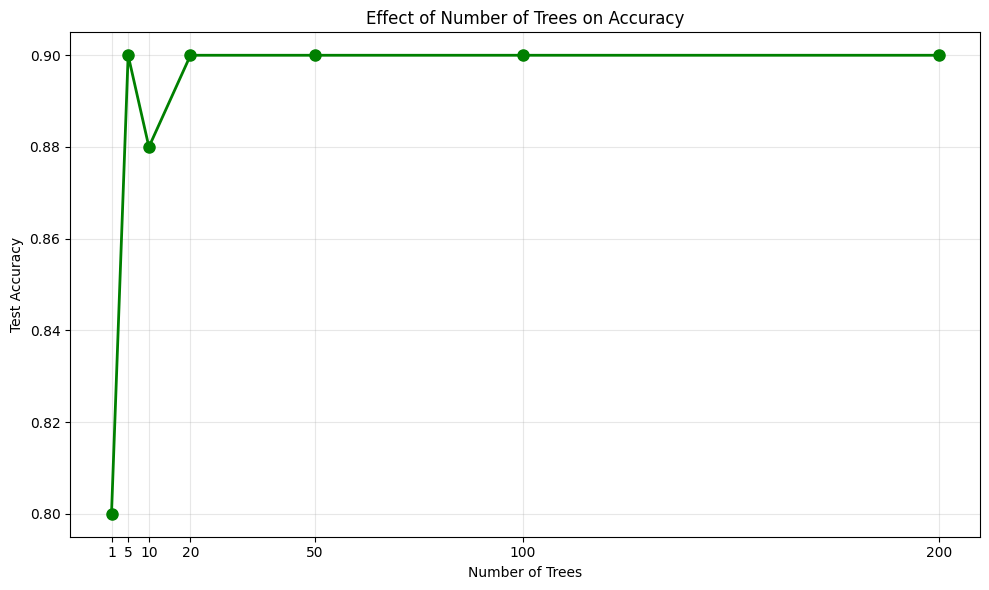

In [29]:
tree_counts = [1, 5, 10, 20, 50, 100, 200]
rf_accuracies = []

for n in tree_counts:
    rf = RandomForestClassifier(
        n_estimators=n, 
        max_depth=best_depth, 
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    rf_accuracies.append(acc)
    print(f"Trees: {n:3} → Accuracy: {acc:.2%}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(tree_counts, rf_accuracies, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Trees')
plt.ylabel('Test Accuracy')
plt.title('Effect of Number of Trees on Accuracy')
plt.grid(True, alpha=0.3)
plt.xticks(tree_counts)
plt.tight_layout()
plt.show()

## 📊 FINAL COMPARISON: ALL MODELS


                             Model Test Accuracy
      Logistic Regression (Day 2)        81.00%
  Decision Tree (depth=2) (Day 3)        89.00%
Random Forest (100 trees) (Day 4)        90.00%


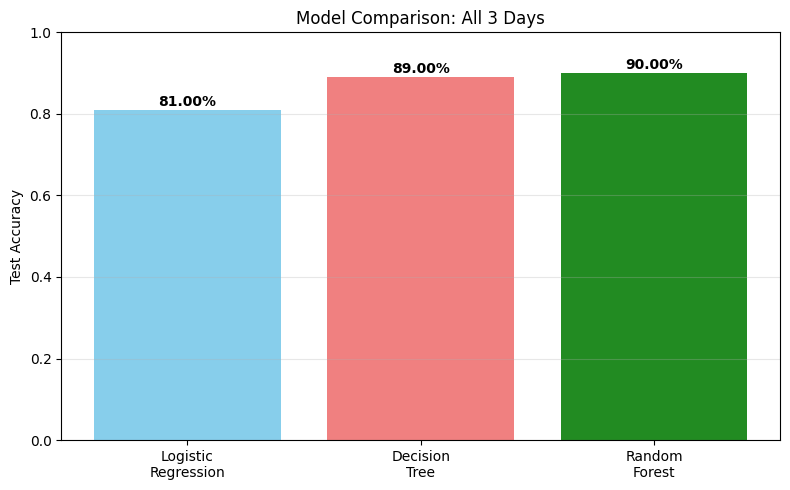

In [30]:
# Comparison
all_models = pd.DataFrame({
    'Model': [
        'Logistic Regression (Day 2)',
        f'Decision Tree (depth={best_depth}) (Day 3)',
        f'Random Forest (100 trees) (Day 4)'
    ],
    'Test Accuracy': [f"{lr_acc:.2%}", f"{best_acc:.2%}", f"{rf_acc:.2%}"]
})

print("\n", all_models.to_string(index=False))

# Bar chart comparison
plt.figure(figsize=(8, 5))
models = ['Logistic\nRegression', f'Decision\nTree', 'Random\nForest']
accs = [lr_acc, best_acc, rf_acc]
colors = ['skyblue', 'lightcoral', 'forestgreen']
bars = plt.bar(models, accs, color=colors)
plt.ylabel('Test Accuracy')
plt.title('Model Comparison: All 3 Days')
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## DAY 5 : Model Evaluation

## RE-TRAIN FINAL MODELS (CLEAN VERSION)

In [31]:
lr_pred = model.predict(X_test_Scaled)
lr_proba = model.predict_proba(X_test_Scaled)[:, 1]


dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)
dt_pred = dt_final.predict(X_test)
dt_proba = dt_final.predict_proba(X_test)[:, 1]


rf_final = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
rf_pred = rf_final.predict(X_test)
rf_proba = rf_final.predict_proba(X_test)[:, 1]


print("✅ Models ready for evaluation")

✅ Models ready for evaluation


In [32]:
results = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, lr_pred),
        'precision': precision_score(y_test, lr_pred),
        'recall': recall_score(y_test, lr_pred),
        'f1': f1_score(y_test, lr_pred)
    },
    'Decision Tree': {
        'accuracy': accuracy_score(y_test, dt_pred),
        'precision': precision_score(y_test, dt_pred),
        'recall': recall_score(y_test, dt_pred),
        'f1': f1_score(y_test, dt_pred)
    },
    'Random Forest': {
        'accuracy': accuracy_score(y_test, rf_pred),
        'precision': precision_score(y_test, rf_pred),
        'recall': recall_score(y_test, rf_pred),
        'f1': f1_score(y_test, rf_pred)
    }
}

print("\n📊 FULL METRIC COMPARISON:")
for model_name, metrics in results.items():
    print(f"\n🔹 {model_name}")
    for metric, value in metrics.items():
        print(f"   {metric:10}: {value:.3f}")


📊 FULL METRIC COMPARISON:

🔹 Logistic Regression
   accuracy  : 0.810
   precision : 0.815
   recall    : 0.611
   f1        : 0.698

🔹 Decision Tree
   accuracy  : 0.890
   precision : 0.821
   recall    : 0.889
   f1        : 0.853

🔹 Random Forest
   accuracy  : 0.900
   precision : 0.842
   recall    : 0.889
   f1        : 0.865


## ROC CURVE COMPARISON

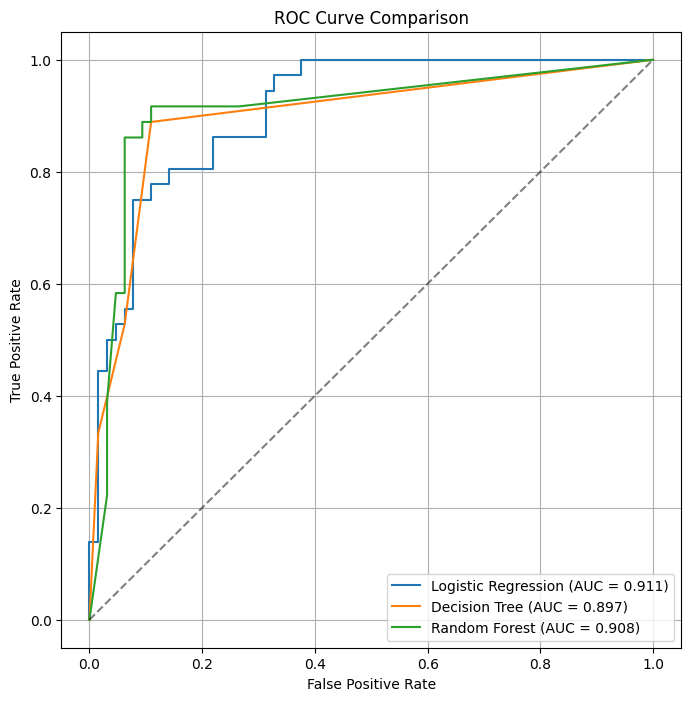

In [33]:
plt.figure(figsize=(8, 8))

for name, proba in [
    ('Logistic Regression', lr_proba),
    ('Decision Tree', dt_proba),
    ('Random Forest', rf_proba)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


 ## SELECT BEST MODEL (BASED ON F1)

In [34]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
print(f"\n🏆 Best model (based on F1): {best_model_name}")


🏆 Best model (based on F1): Random Forest


## THRESHOLD TUNING 

In [35]:
print("\n🎯 Threshold Tuning (for best model)")

if best_model_name == 'Logistic Regression':
    best_proba = lr_proba
elif best_model_name == 'Decision Tree':
    best_proba = dt_proba
else:
    best_proba = rf_proba

thresholds = np.linspace(0.2, 0.8, 7)

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    print(f"Threshold {t:.2f} → F1: {f1_score(y_test, y_pred_t):.3f}, "
          f"Recall: {recall_score(y_test, y_pred_t):.3f}, "
          f"Precision: {precision_score(y_test, y_pred_t):.3f}")


🎯 Threshold Tuning (for best model)
Threshold 0.20 → F1: 0.857, Recall: 0.917, Precision: 0.805
Threshold 0.30 → F1: 0.868, Recall: 0.917, Precision: 0.825
Threshold 0.40 → F1: 0.853, Recall: 0.889, Precision: 0.821
Threshold 0.50 → F1: 0.865, Recall: 0.889, Precision: 0.842
Threshold 0.60 → F1: 0.873, Recall: 0.861, Precision: 0.886
Threshold 0.70 → F1: 0.841, Recall: 0.806, Precision: 0.879
Threshold 0.80 → F1: 0.806, Recall: 0.750, Precision: 0.871
